In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_online_probing(theta1_0, theta2_0, eta, num_steps):
    """
    Simulate online mutual probing between two learners.
    Each learner probes the other at each timestep.
    """
    theta1 = np.zeros(num_steps + 1)
    theta2 = np.zeros(num_steps + 1)
    
    theta1[0] = theta1_0
    theta2[0] = theta2_0
    
    for t in range(num_steps):
        # Learner 1 probes learner 2 (using current theta2)
        # Learner 2 probes learner 1 (using current theta1)
        theta1[t+1] = theta1[t] - 2*eta*(theta1[t] - theta2[t])
        theta2[t+1] = theta2[t] - 2*eta*(theta2[t] - theta1[t])
    
    return theta1, theta2

def simulate_offline_probing(theta1_0, theta2_0, eta, num_steps):
    """
    Simulate offline probing between two learners.
    Each learner probes the other's INITIAL state (fixed target).
    """
    theta1 = np.zeros(num_steps + 1)
    theta2 = np.zeros(num_steps + 1)
    
    theta1[0] = theta1_0
    theta2[0] = theta2_0
    
    for t in range(num_steps):
        # Learner 1 probes learner 2's initial state (theta2_0)
        # Learner 2 probes learner 1's initial state (theta1_0)
        theta1[t+1] = theta1[t] - 2*eta*(theta1[t] - theta2_0)
        theta2[t+1] = theta2[t] - 2*eta*(theta2[t] - theta1_0)
    
    return theta1, theta2

In [3]:
# Simulation parameters
theta1_0 = 1.0
theta2_0 = -1.0
num_steps = 50

# Different learning rates
learning_rates = {
    'Perfect Oscillation (η=0.5)': 0.5,
    'Damped Oscillation (η=0.3)': 0.3,
    'Slow Convergence (η=0.1)': 0.1,
    'Divergent (η=0.6)': 0.6
}

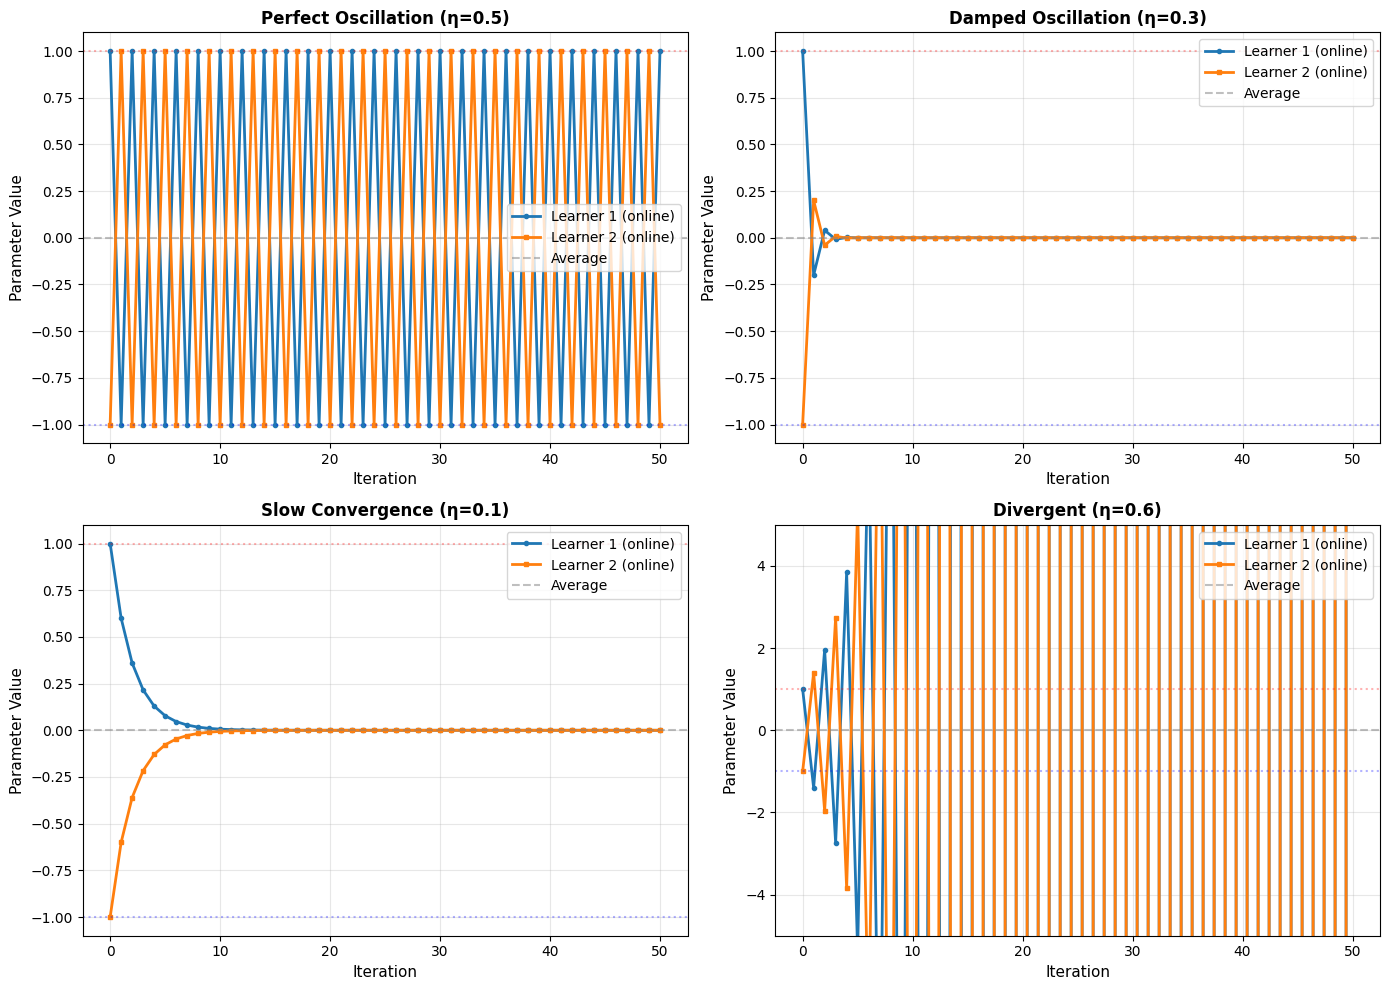

In [5]:

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (title, eta) in enumerate(learning_rates.items()):
    theta1_online, theta2_online = simulate_online_probing(theta1_0, theta2_0, eta, num_steps)
    
    ax = axes[idx]
    ax.plot(theta1_online, label='Learner 1 (online)', linewidth=2, marker='o', markersize=3)
    ax.plot(theta2_online, label='Learner 2 (online)', linewidth=2, marker='s', markersize=3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Average')
    ax.axhline(y=theta1_0, color='red', linestyle=':', alpha=0.3)
    ax.axhline(y=theta2_0, color='blue', linestyle=':', alpha=0.3)
    
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Parameter Value', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Set y-limits for divergent case
    if eta == 0.6:
        ax.set_ylim(-5, 5)

plt.tight_layout()
plt.savefig('online_probing_oscillations.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Now compare online vs offline probing
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

comparison_etas = [0.5, 0.3, 0.1]

for idx, eta in enumerate(comparison_etas):
    theta1_online, theta2_online = simulate_online_probing(theta1_0, theta2_0, eta, num_steps)
    theta1_offline, theta2_offline = simulate_offline_probing(theta1_0, theta2_0, eta, num_steps)
    
    ax = axes[idx]
    
    # Plot online probing
    ax.plot(theta1_online, label='Learner 1 (online)', 
            linewidth=2, linestyle='-', alpha=0.7, color='red')
    ax.plot(theta2_online, label='Learner 2 (online)', 
            linewidth=2, linestyle='-', alpha=0.7, color='blue')
    
    # Plot offline probing
    ax.plot(theta1_offline, label='Learner 1 (offline)', 
            linewidth=2, linestyle='--', alpha=0.9, color='darkred')
    ax.plot(theta2_offline, label='Learner 2 (offline)', 
            linewidth=2, linestyle='--', alpha=0.9, color='darkblue')
    
    ax.axhline(y=theta2_0, color='darkred', linestyle=':', alpha=0.3, label='θ₁ target (offline)')
    ax.axhline(y=theta1_0, color='darkblue', linestyle=':', alpha=0.3, label='θ₂ target (offline)')
    
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Parameter Value', fontsize=11)
    ax.set_title(f'Online vs Offline Probing (η={eta})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('online_vs_offline_probing.png', dpi=150, bbox_inches='tight')
plt.show()

# Phase portrait for η=0.5 (perfect oscillation)
print("\n" + "="*60)
print("PHASE PORTRAIT: Online Probing with η=0.5")
print("="*60)

eta = 0.5
theta1_online, theta2_online = simulate_online_probing(theta1_0, theta2_0, eta, num_steps)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.plot(theta1_online, theta2_online, 'o-', linewidth=2, markersize=6, alpha=0.7)
ax.plot(theta1_online[0], theta2_online[0], 'go', markersize=15, label='Start', zorder=5)
ax.plot(theta1_online[-1], theta2_online[-1], 'ro', markersize=15, label='End', zorder=5)

# Add arrows to show direction
for i in range(0, len(theta1_online)-1, 5):
    dx = theta1_online[i+1] - theta1_online[i]
    dy = theta2_online[i+1] - theta2_online[i]
    ax.arrow(theta1_online[i], theta2_online[i], dx*0.5, dy*0.5, 
             head_width=0.1, head_length=0.1, fc='black', ec='black', alpha=0.5)

ax.axline((0, 0), slope=1, color='gray', linestyle='--', alpha=0.5, label='θ₁=θ₂')
ax.set_xlabel('θ₁', fontsize=13)
ax.set_ylabel('θ₂', fontsize=13)
ax.set_title('Phase Portrait: Perfect Oscillation (η=0.5)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('phase_portrait.png', dpi=150, bbox_inches='tight')
plt.show()

# Eigenvalue analysis
print("\n" + "="*60)
print("EIGENVALUE ANALYSIS")
print("="*60)

for eta_name, eta in learning_rates.items():
    A = np.array([[1-2*eta, 2*eta],
                  [2*eta, 1-2*eta]])
    eigenvalues = np.linalg.eigvals(A)
    
    print(f"\n{eta_name}:")
    print(f"  Matrix eigenvalues: {eigenvalues}")
    print(f"  λ₁ = {eigenvalues[0]:.4f}")
    print(f"  λ₂ = {eigenvalues[1]:.4f}")
    
    if np.abs(eigenvalues[1]) > 1:
        print(f"  → DIVERGENT (|λ₂| > 1)")
    elif eigenvalues[1] < 0:
        print(f"  → OSCILLATORY (λ₂ < 0)")
    else:
        print(f"  → CONVERGENT")

# Show what happens with 3 learners (cyclic probing)
print("\n" + "="*60)
print("3-LEARNER CYCLIC PROBING")
print("="*60)

def simulate_cyclic_probing(theta_init, eta, num_steps):
    """
    3 learners in a cycle: 1 → 2 → 3 → 1
    Learner 1 probes 2, Learner 2 probes 3, Learner 3 probes 1
    """
    n_learners = len(theta_init)
    theta = np.zeros((n_learners, num_steps + 1))
    theta[:, 0] = theta_init
    
    for t in range(num_steps):
        # Each learner probes the next one in the cycle
        for i in range(n_learners):
            target_idx = (i + 1) % n_learners
            theta[i, t+1] = theta[i, t] - 2*eta*(theta[i, t] - theta[target_idx, t])
    
    return theta

theta_init_3 = np.array([1.0, 0.0, -1.0])
eta = 0.3
theta_3 = simulate_cyclic_probing(theta_init_3, eta, 100)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
for i in range(3):
    ax.plot(theta_3[i], label=f'Learner {i+1}', linewidth=2, marker='o', 
            markersize=3, markevery=5)

ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Parameter Value', fontsize=11)
ax.set_title('3-Learner Cyclic Online Probing (1→2→3→1, η=0.3)', 
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cyclic_probing_3_learners.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization complete! Generated plots:")
print("  1. online_probing_oscillations.png - Different learning rates")
print("  2. online_vs_offline_probing.png - Direct comparison")
print("  3. phase_portrait.png - State space visualization")
print("  4. cyclic_probing_3_learners.png - 3-learner cycle")